# Analysis Context Length

## Setup

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

metrics_dir = Path("../results/metrics")
json_files  = sorted(metrics_dir.glob("context_len*.json"))

records = []
for path in json_files:
    with open(path) as f:
        d = json.load(f)
    records.append(d)

records = sorted(records, key=lambda x: x["prompt_length"])

lengths  = [r["prompt_length"] for r in records]
ttft_p50 = [r["ttft_p50_ms"]   for r in records]

print("Context length data (from JSON):")
for r in records:
    print(f"  label={r['label']:20s} "
          f"prompt_length={r['prompt_length']:4d} "
          f"ttft_p50={r['ttft_p50_ms']:.1f}ms "
          f"ttft_p90={r['ttft_p90_ms']:.1f}ms")

print("\nNote: p90/p99 not used — warmup artifact inflates values.")
print("Analysis uses p50 only.")

Context length data (from JSON):
  label=context_len(32)      prompt_length=  34 ttft_p50=61.5ms ttft_p90=435.1ms
  label=context_len(64)      prompt_length=  67 ttft_p50=59.9ms ttft_p90=60.0ms
  label=context_len(128)     prompt_length= 133 ttft_p50=62.0ms ttft_p90=62.5ms
  label=context_len(256)     prompt_length= 265 ttft_p50=60.2ms ttft_p90=79.2ms
  label=context_len(512)     prompt_length= 518 ttft_p50=114.9ms ttft_p90=115.4ms
  label=context_len(1024)    prompt_length=1024 ttft_p50=288.6ms ttft_p90=291.9ms

Note: p90/p99 not used — warmup artifact inflates values.
Analysis uses p50 only.


## TTFT vs Prompt Length

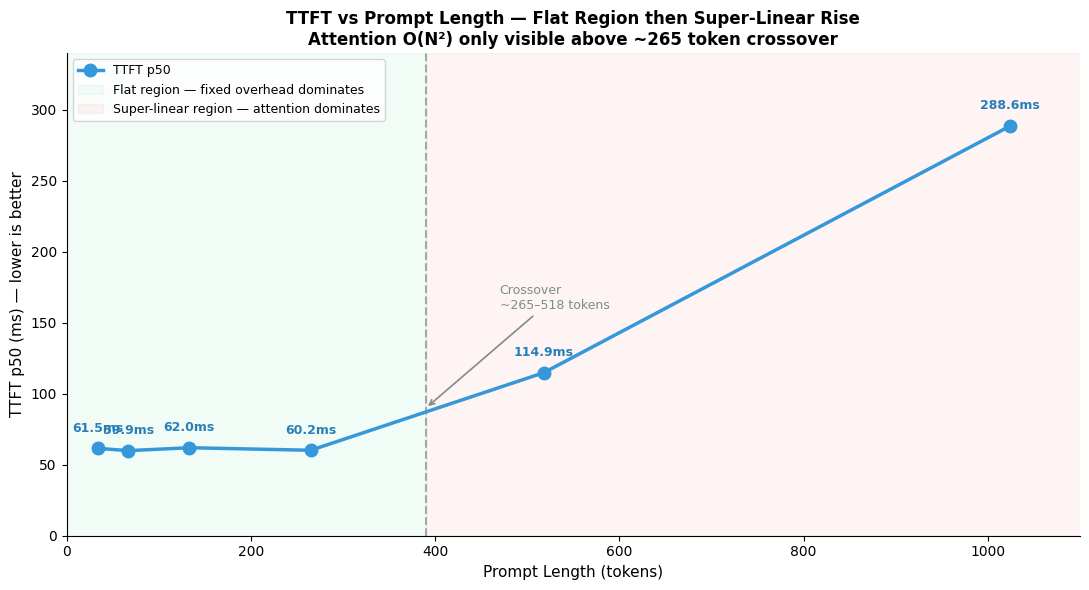

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(lengths, ttft_p50,
        color="#3498db", marker="o", linewidth=2.5,
        markersize=9, label="TTFT p50", zorder=5)

for x, y in zip(lengths, ttft_p50):
    ax.annotate(f"{y:.1f}ms",
                (x, y), textcoords="offset points",
                xytext=(0, 12), ha="center",
                fontsize=9, fontweight="bold", color="#2980b9")

crossover_x = 390
ax.axvspan(0, crossover_x, alpha=0.06, color="#2ecc71",
           label="Flat region — fixed overhead dominates")
ax.axvspan(crossover_x, 1100, alpha=0.06, color="#e74c3c",
           label="Super-linear region — attention dominates")

ax.axvline(x=crossover_x, color="#7f8c8d",
           linestyle="--", linewidth=1.5, alpha=0.7)
ax.annotate("Crossover\n~265–518 tokens",
            xy=(crossover_x, 90),
            xytext=(crossover_x + 80, 160),
            fontsize=9, color="#7f8c8d",
            arrowprops=dict(arrowstyle="->", color="#7f8c8d", lw=1.2))

ax.set_xlabel("Prompt Length (tokens)", fontsize=11)
ax.set_ylabel("TTFT p50 (ms) — lower is better", fontsize=11)
ax.set_title("TTFT vs Prompt Length — Flat Region then Super-Linear Rise\n"
             "Attention O(N²) only visible above ~265 token crossover",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.set_xlim(0, 1100)
ax.set_ylim(0, 340)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
Path("../results/figures/context_length").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/context_length/ttft_vs_prompt_length.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Scaling Ratio: Actual vs Theoretical

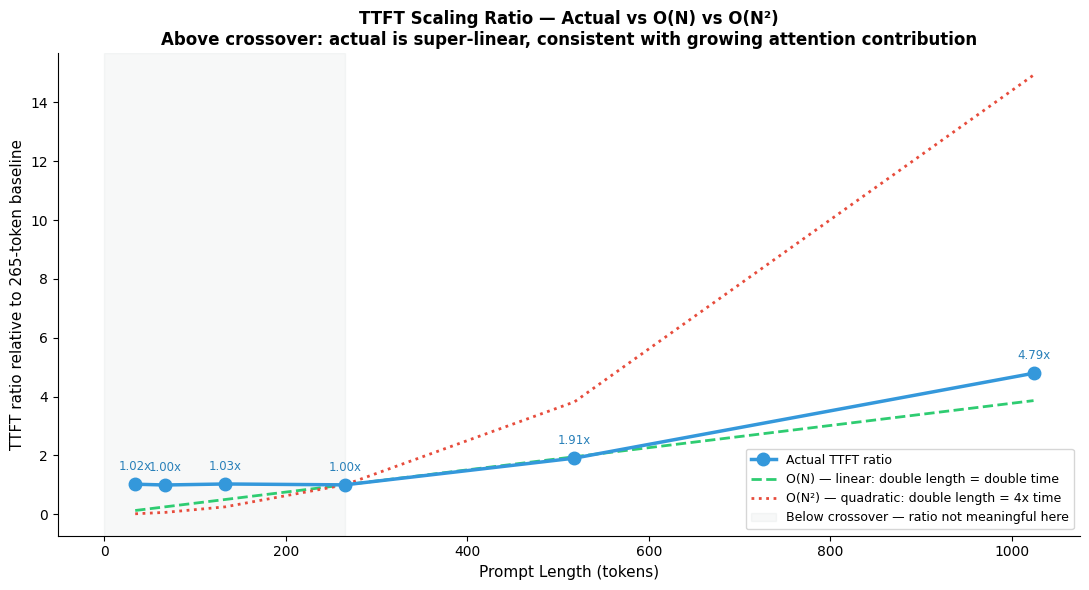

Scaling analysis (baseline = 265 tokens, 60.2ms):
  Length   Actual     O(N)      O(N²)    vs O(N)
      34     1.02x     0.13x       0.02x       slower
      67     1.00x     0.25x       0.06x       slower
     133     1.03x     0.50x       0.25x       slower
     265     1.00x     1.00x       1.00x       slower
     518     1.91x     1.95x       3.82x       faster
    1024     4.79x     3.86x      14.93x       slower


In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

baseline_idx  = lengths.index(265)
baseline_len  = lengths[baseline_idx]
baseline_ttft = ttft_p50[baseline_idx]

actual_ratio          = [t / baseline_ttft for t in ttft_p50]
theoretical_linear    = [l / baseline_len  for l in lengths]
theoretical_quadratic = [(l / baseline_len)**2 for l in lengths]

ax.plot(lengths, actual_ratio,
        color="#3498db", marker="o", linewidth=2.5,
        markersize=9, label="Actual TTFT ratio", zorder=5)

ax.plot(lengths, theoretical_linear,
        color="#2ecc71", linewidth=2, linestyle="--",
        label="O(N) — linear: double length = double time")

ax.plot(lengths, theoretical_quadratic,
        color="#e74c3c", linewidth=2, linestyle=":",
        label="O(N²) — quadratic: double length = 4x time")

for x, y in zip(lengths, actual_ratio):
    ax.annotate(f"{y:.2f}x",
                (x, y), textcoords="offset points",
                xytext=(0, 10), ha="center",
                fontsize=8.5, color="#2980b9")

ax.axvspan(0, 265, alpha=0.06, color="#7f8c8d",
           label="Below crossover — ratio not meaningful here")

ax.set_xlabel("Prompt Length (tokens)", fontsize=11)
ax.set_ylabel(f"TTFT ratio relative to {baseline_len}-token baseline",
              fontsize=11)
ax.set_title("TTFT Scaling Ratio — Actual vs O(N) vs O(N²)\n"
             "Above crossover: actual is super-linear, "
             "consistent with growing attention contribution",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/context_length/scaling_ratio.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Scaling analysis (baseline = {baseline_len} tokens, {baseline_ttft:.1f}ms):")
print(f"{'Length':>8} {'Actual':>8} {'O(N)':>8} {'O(N²)':>10} {'vs O(N)':>10}")
for l, a, lin, quad in zip(lengths, actual_ratio,
                            theoretical_linear, theoretical_quadratic):
    vs_linear = "faster" if a < lin else "slower"
    print(f"{l:>8} {a:>8.2f}x {lin:>8.2f}x {quad:>10.2f}x "
          f"{'':>2}{vs_linear:>10}")

## TTFT Breakdown

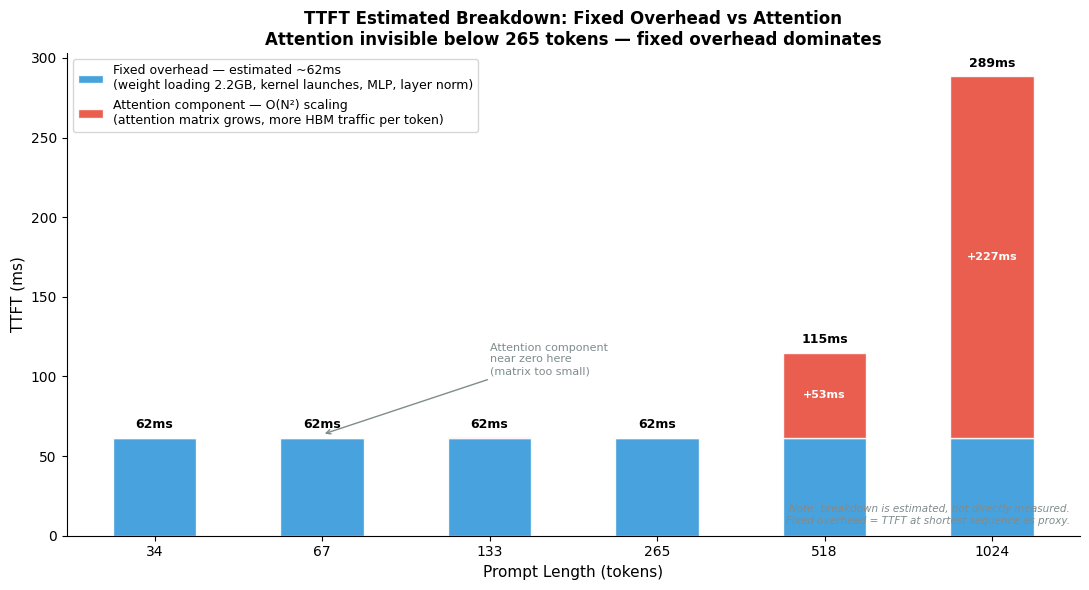


Attention component as % of total TTFT:
  len=  34: fixed=61.5ms, attention=0.0ms (0.0% of total 61.5ms)
  len=  67: fixed=61.5ms, attention=0.0ms (0.0% of total 61.5ms)
  len= 133: fixed=61.5ms, attention=0.5ms (0.7% of total 62.0ms)
  len= 265: fixed=61.5ms, attention=0.0ms (0.0% of total 61.5ms)
  len= 518: fixed=61.5ms, attention=53.3ms (46.4% of total 114.9ms)
  len=1024: fixed=61.5ms, attention=227.1ms (78.7% of total 288.6ms)


In [15]:
fig, ax = plt.subplots(figsize=(11, 6))

fixed_overhead      = ttft_p50[0]
attention_component = [max(0, t - fixed_overhead) for t in ttft_p50]
fixed_components    = [fixed_overhead] * len(lengths)

x     = np.arange(len(lengths))
width = 0.5

ax.bar(x, fixed_components, width,
       label=f"Fixed overhead — estimated ~{fixed_overhead:.0f}ms\n"
             f"(weight loading 2.2GB, kernel launches, MLP, layer norm)",
       color="#3498db", edgecolor="white", alpha=0.9)

ax.bar(x, attention_component, width,
       bottom=fixed_components,
       label="Attention component — O(N²) scaling\n"
             "(attention matrix grows, more HBM traffic per token)",
       color="#e74c3c", edgecolor="white", alpha=0.9)

for i, (fc, ac) in enumerate(zip(fixed_components, attention_component)):
    total = fc + ac
    ax.text(x[i], total + 4, f"{total:.0f}ms",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold")
    if ac > 5:
        ax.text(x[i], fc + ac/2, f"+{ac:.0f}ms",
                ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")

ax.annotate("Attention component\nnear zero here\n(matrix too small)",
            xy=(1, fixed_overhead + 2),
            xytext=(2, fixed_overhead + 40),
            fontsize=8, color="#7f8c8d",
            arrowprops=dict(arrowstyle="->",
                           color="#7f8c8d", lw=1))

ax.set_xticks(x)
ax.set_xticklabels([str(l) for l in lengths])
ax.set_xlabel("Prompt Length (tokens)", fontsize=11)
ax.set_ylabel("TTFT (ms)", fontsize=11)
ax.set_title("TTFT Estimated Breakdown: Fixed Overhead vs Attention\n"
             "Attention invisible below 265 tokens — fixed overhead dominates",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(0.99, 0.02,
        "Note: breakdown is estimated, not directly measured.\n"
        "Fixed overhead = TTFT at shortest sequence as proxy.",
        transform=ax.transAxes,
        fontsize=7.5, ha="right", va="bottom",
        color="#7f8c8d", style="italic")

plt.tight_layout()
plt.savefig("../results/figures/context_length/ttft_breakdown.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nAttention component as % of total TTFT:")
for l, fc, ac in zip(lengths, fixed_components, attention_component):
    total = fc + ac
    pct   = (ac / total) * 100
    print(f"  len={l:4d}: "
          f"fixed={fc:.1f}ms, "
          f"attention={ac:.1f}ms ({pct:.1f}% of total {total:.1f}ms)")